# Employee Salary & Performance Analysis - EDA Project

## Objective

Analyze employee data to identify patterns, trends, relationships, and key factors affecting salary and performance.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Creating Employee Dataset

A synthetic employee dataset is created for exploratory data analysis.

In [2]:
np.random.seed(42)

records = 1000


employee_id = range(1001, 1001+records)

age = np.random.randint(22,60,records)

gender = np.random.choice(
    ["Male","Female"],
    records
)

education = np.random.choice(
    ["Bachelor","Master","PhD"],
    records
)

experience = np.random.randint(
    0,35,
    records
)

department = np.random.choice(
    [
        "IT",
        "HR",
        "Finance",
        "Marketing",
        "Sales"
    ],
    records
)

job_level = np.random.choice(
    [
        "Junior",
        "Mid",
        "Senior"
    ],
    records
)

monthly_salary = (
    25000 +
    experience*3000 +
    np.random.randint(
        0,
        50000,
        records
    )
)

performance = np.random.randint(
    1,
    10,
    records
)

working_hours = np.random.randint(
    120,
    240,
    records
)

satisfaction = np.random.randint(
    1,
    10,
    records
)

In [3]:
df = pd.DataFrame({

    "Employee_ID": employee_id,
    "Age": age,
    "Gender": gender,
    "Education": education,
    "Experience": experience,
    "Department": department,
    "Job_Level": job_level,
    "Monthly_Salary": monthly_salary,
    "Performance_Score": performance,
    "Working_Hours": working_hours,
    "Satisfaction_Score": satisfaction

})


df.head()

,Employee_ID,Age,Gender,Education,Experience,Department,Job_Level,Monthly_Salary,Performance_Score,Working_Hours,Satisfaction_Score
0,1001,50,Female,Master,4,Marketing,Junior,65379,2,147,1
1,1002,36,Male,PhD,2,Marketing,Junior,73939,8,164,7
2,1003,29,Male,Master,22,Sales,Mid,116274,9,136,1
3,1004,42,Male,Master,25,Finance,Junior,117696,4,159,7
4,1005,40,Male,PhD,23,IT,Junior,96962,9,235,8


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         1000 non-null   int64 
 1   Age                 1000 non-null   int64 
 2   Gender              1000 non-null   object
 3   Education           1000 non-null   object
 4   Experience          1000 non-null   int64 
 5   Department          1000 non-null   object
 6   Job_Level           1000 non-null   object
 7   Monthly_Salary      1000 non-null   int64 
 8   Performance_Score   1000 non-null   int64 
 9   Working_Hours       1000 non-null   int64 
 10  Satisfaction_Score  1000 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 86.1+ KB


In [5]:
df.shape

(1000, 11)

In [6]:
df.describe()

,Employee_ID,Age,Experience,Monthly_Salary,Performance_Score,Working_Hours,Satisfaction_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,40.947000,17.311000,101448.521000,4.940000,181.011000,4.958000
std,288.819436,11.160858,10.108336,34086.520143,2.548508,35.597135,2.686904
min,1001.000000,22.000000,0.000000,25215.000000,1.000000,120.000000,1.000000
25%,1250.750000,31.000000,9.000000,75774.750000,3.000000,149.000000,3.000000
50%,1500.500000,42.000000,18.000000,101738.000000,5.000000,181.000000,5.000000
75%,1750.250000,50.000000,26.000000,129021.750000,7.000000,213.000000,7.000000
max,2000.000000,59.000000,34.000000,176793.000000,9.000000,239.000000,9.000000


In [7]:
df.isnull().sum()

,0
Employee_ID,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
Job_Level,0
Monthly_Salary,0
Performance_Score,0
Working_Hours,0


In [8]:
df.head()

,Employee_ID,Age,Gender,Education,Experience,Department,Job_Level,Monthly_Salary,Performance_Score,Working_Hours,Satisfaction_Score
0,1001,50,Female,Master,4,Marketing,Junior,65379,2,147,1
1,1002,36,Male,PhD,2,Marketing,Junior,73939,8,164,7
2,1003,29,Male,Master,22,Sales,Mid,116274,9,136,1
3,1004,42,Male,Master,25,Finance,Junior,117696,4,159,7
4,1005,40,Male,PhD,23,IT,Junior,96962,9,235,8


In [9]:
df.to_csv(
    "employee_data.csv",
    index=False
)

print("Dataset saved!")

Dataset saved!


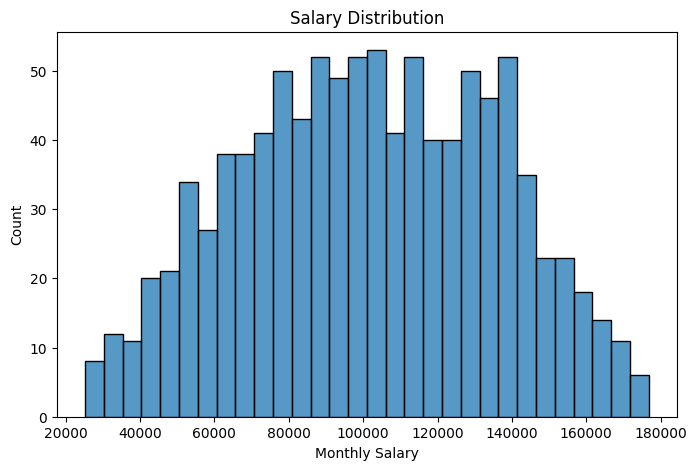

In [10]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Monthly_Salary"],
    bins=30
)

plt.title("Salary Distribution")

plt.xlabel("Monthly Salary")

plt.show()

In [11]:
department_salary = df.groupby(
    "Department"
)["Monthly_Salary"].mean()


department_salary

,Monthly_Salary
Department,
Finance,99542.758140
HR,103795.757732
IT,104553.745098
Marketing,100209.583333
Sales,99185.882051


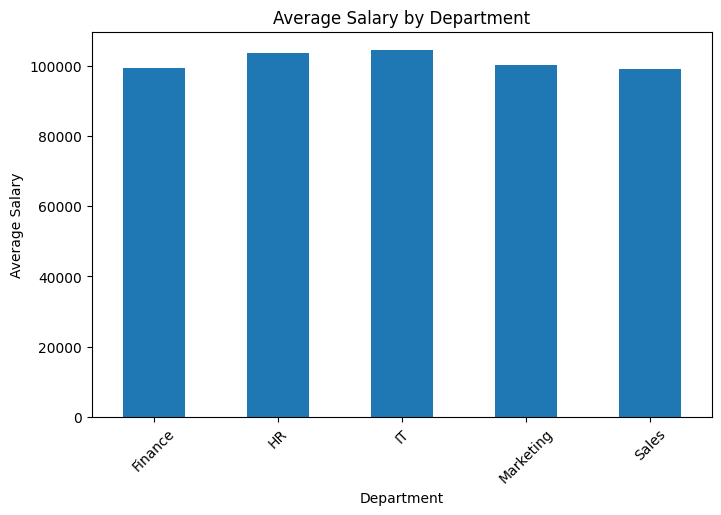

In [12]:
plt.figure(figsize=(8,5))

department_salary.plot(
    kind="bar"
)

plt.title("Average Salary by Department")

plt.xlabel("Department")

plt.ylabel("Average Salary")

plt.xticks(rotation=45)

plt.show()

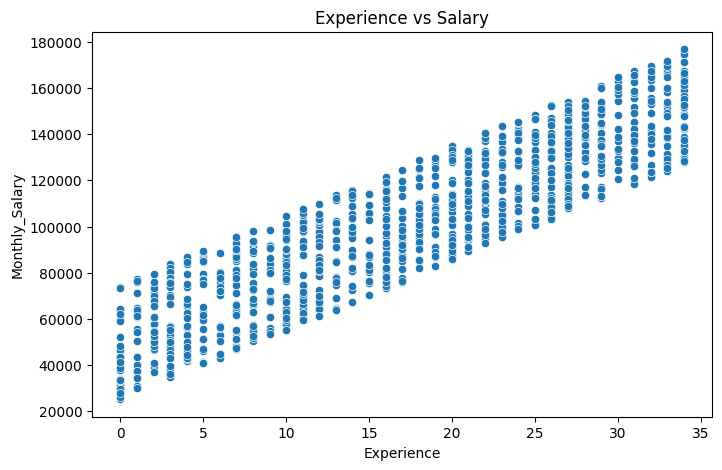

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Experience",
    y="Monthly_Salary"
)

plt.title("Experience vs Salary")

plt.show()

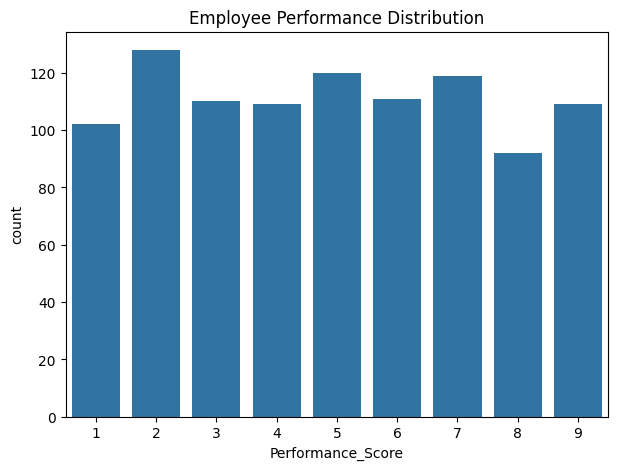

In [14]:
plt.figure(figsize=(7,5))

sns.countplot(
    x=df["Performance_Score"]
)

plt.title("Employee Performance Distribution")

plt.show()

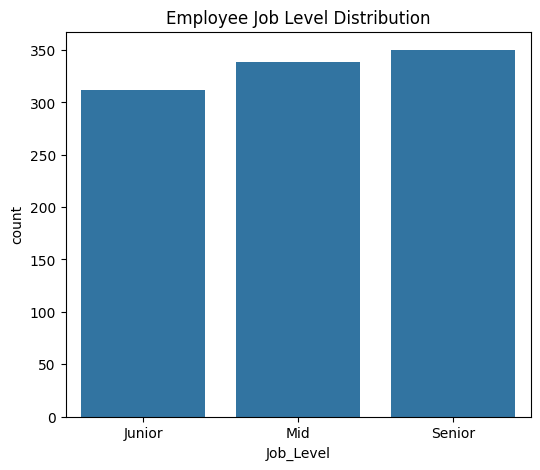

In [15]:
plt.figure(figsize=(6,5))

sns.countplot(
    x=df["Job_Level"]
)

plt.title("Employee Job Level Distribution")

plt.show()

In [16]:
numeric_data = df[
    [
        "Age",
        "Experience",
        "Monthly_Salary",
        "Performance_Score",
        "Working_Hours",
        "Satisfaction_Score"
    ]
]

In [17]:
correlation = numeric_data.corr()

correlation

,Age,Experience,Monthly_Salary,Performance_Score,Working_Hours,Satisfaction_Score
Age,1.000000,-0.031751,-0.025608,-0.045546,-0.002054,-0.002378
Experience,-0.031751,1.000000,0.901472,0.020154,0.000285,-0.022811
Monthly_Salary,-0.025608,0.901472,1.000000,0.020088,-0.001126,-0.022944
Performance_Score,-0.045546,0.020154,0.020088,1.000000,-0.031870,0.041001
Working_Hours,-0.002054,0.000285,-0.001126,-0.031870,1.000000,0.010115
Satisfaction_Score,-0.002378,-0.022811,-0.022944,0.041001,0.010115,1.000000


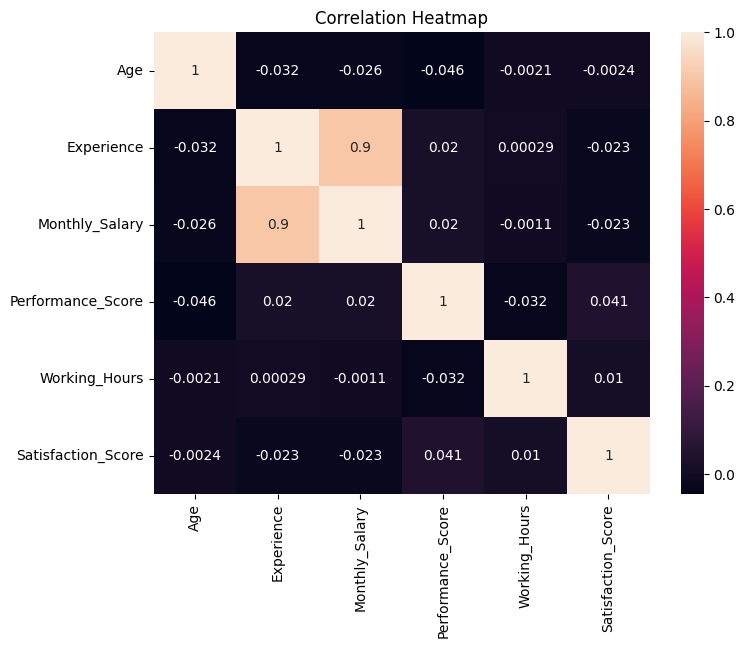

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True
)

plt.title(
    "Correlation Heatmap"
)

plt.show()

In [19]:
education_salary = df.groupby(
    "Education"
)["Monthly_Salary"].mean()


education_salary

,Monthly_Salary
Education,
Bachelor,100612.562682
Master,100542.602273
PhD,103434.150820


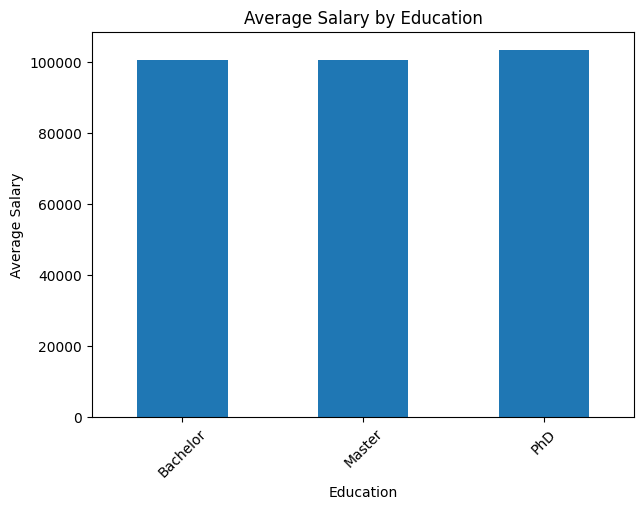

In [20]:
plt.figure(figsize=(7,5))

education_salary.plot(
    kind="bar"
)

plt.title(
    "Average Salary by Education"
)

plt.ylabel(
    "Average Salary"
)

plt.xticks(rotation=45)

plt.show()

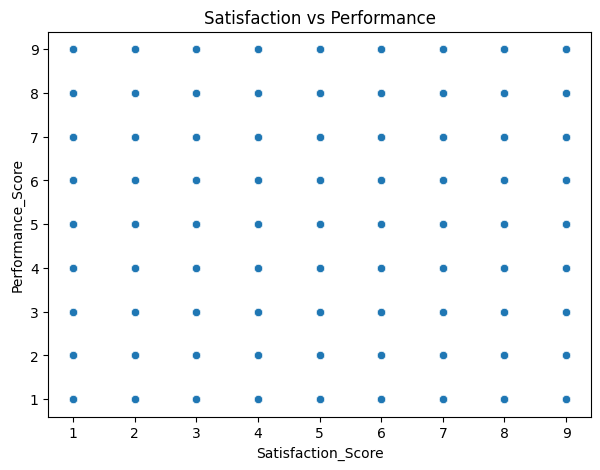

In [21]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="Satisfaction_Score",
    y="Performance_Score"
)

plt.title(
    "Satisfaction vs Performance"
)

plt.show()

# Key Insights

1. Employee experience has a positive relationship with salary.

2. Some departments have higher average salaries compared to others.

3. Higher education levels generally show better salary opportunities.

4. Performance scores help identify employee contribution levels.

5. Employee satisfaction and performance show a relationship.

# Conclusion

This EDA project analyzed employee salary and performance data to identify important patterns and trends.

The analysis included statistical summaries, data visualization, and correlation analysis.

The findings help understand factors influencing salary, performance, and employee satisfaction.